# Snow Water Equivalent (SWE) Data: Convert, Clean & Vegetation-Filter Pipeline

**Purpose:** Process the raw gridded Snow Water Equivalent (SWE) NetCDF
(1994–2020, daily), validate spatial alignment with the weather reanalysis grid,
check missing rates, convert to Parquet, and spatially filter to only the
grid cells with combustible vegetation.

**Pipeline Overview:**

| Phase | Steps |
|-------|-------|
| **A. Inspect & Convert** | Load `.nc`, drop unused variable (`DEPTH`), inspect dimensions, QA grid alignment with weather data, check missing rates, save to Parquet |
| **B. Vegetation Filter** | Inner-join with combustible-vegetation grid (exclude Water, Urban, Agriculture), validate missing rates post-filter, save final Parquet |

**Inputs:**
- `Extended_Data/Snow_Data/SWE.WY.1994.2020.CA.interpolated.nc` — daily SWE (+ DEPTH, dropped)
- `Clean_Data/Weather_Data/Extended_Weather_Data/wind_speed.parquet` — reference weather grid
- `Clean_Data/Veg_Data/lon_lat_pair_weather_match_veg_v2.parquet` — vegetation-filtered grid

**Outputs:**
- `Clean_Data/Snow_Data/SWE.parquet` — vegetation-filtered daily SWE panel

## 0. Configuration

Centralized path configuration — **edit this cell only** to adapt to your local setup.

In [1]:
import os

# ====================== EDIT THESE PATHS ======================
PROJECT_ROOT = r"E:\zcao\CA_Wildfire"

# Input paths
SNOW_DATA_DIR  = os.path.join(PROJECT_ROOT, "Extended_Data", "Snow_Data")
SNOW_FILE      = "SWE.WY.1994.2020.CA.interpolated.nc"

# Reference grid (any single-day parquet from the weather pipeline)
WEATHER_REF_PATH = os.path.join(
    PROJECT_ROOT, "Clean_Data", "Weather_Data",
    "Extended_Weather_Data", "wind_speed.parquet"
)

# Vegetation v2 grid produced by 00_Veg_Weather_Grid_Match.ipynb
VEG_V2_PATH = os.path.join(
    PROJECT_ROOT, "Clean_Data", "Veg_Data",
    "lon_lat_pair_weather_match_veg_v2.parquet"
)

# Output directory
SNOW_CLEAN_DIR = os.path.join(PROJECT_ROOT, "Clean_Data", "Snow_Data")
os.makedirs(SNOW_CLEAN_DIR, exist_ok=True)

print(f"Snow data dir   : {SNOW_DATA_DIR}")
print(f"Snow file       : {SNOW_FILE}")
print(f"Output dir      : {SNOW_CLEAN_DIR}")
print(f"Veg v2 path     : {VEG_V2_PATH}")
print(f"Weather ref     : {WEATHER_REF_PATH}")

Snow data dir   : E:\zcao\CA_Wildfire\Extended_Data\Snow_Data
Snow file       : SWE.WY.1994.2020.CA.interpolated.nc
Output dir      : E:\zcao\CA_Wildfire\Clean_Data\Snow_Data
Veg v2 path     : E:\zcao\CA_Wildfire\Clean_Data\Veg_Data\lon_lat_pair_weather_match_veg_v2.parquet
Weather ref     : E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Extended_Weather_Data\wind_speed.parquet


## 1. Environment Setup

In [2]:
import sys
import gc
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import pyproj
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm

gc.collect()

print(f"Python    : {sys.version.split('|')[0].strip()}")
print(f"pandas    : {pd.__version__}")
print(f"xarray    : {xr.__version__}")
print(f"numpy     : {np.__version__}")
print(f"pyproj    : {pyproj.__version__}")
print(f"geopandas : {gpd.__version__}")

Python    : 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
pandas    : 2.2.2
xarray    : 2024.7.0
numpy     : 1.24.4
pyproj    : 3.6.1
geopandas : 0.14.3


---

# Phase A: Inspect & Convert SWE NetCDF

Load the raw NetCDF file, inspect its structure, drop the unused `DEPTH` variable,
convert to a flat DataFrame, verify spatial alignment with the weather grid,
check missing rates, and save to Parquet.

## 2. Discover & Inspect Input File

List available `.nc` files and print key metadata — dimensions, time range,
coordinates, and data variables — before loading the full dataset.

In [3]:
all_files = os.listdir(SNOW_DATA_DIR)
nc_files  = [f for f in all_files if f.endswith('.nc')]

print(f"Total files in dir : {len(all_files)}")
print(f"NetCDF (.nc) files : {len(nc_files)}")
for f in nc_files:
    print(f"  {f}")

Total files in dir : 1
NetCDF (.nc) files : 1
  SWE.WY.1994.2020.CA.interpolated.nc


In [4]:
ds = xr.open_dataset(os.path.join(SNOW_DATA_DIR, SNOW_FILE))

print(f"File            : {SNOW_FILE}")
print(f"Dimensions      : {dict(ds.dims)}")
print(f"Time range      : {str(ds.coords['time'].min().values)[:10]}"
      f" to {str(ds.coords['time'].max().values)[:10]}")
print(f"Coordinates     : {list(ds.coords)}")
print(f"Data variables  : {list(ds.data_vars)}")

File            : SWE.WY.1994.2020.CA.interpolated.nc
Dimensions      : {'time': 9862, 'lat': 238, 'lon': 258}
Time range      : 1993-10-01 to 2020-09-30
Coordinates     : ['time', 'lat', 'lon']
Data variables  : ['SWE', 'DEPTH']


## 3. Drop Unused Variable: `DEPTH`

The NetCDF ships with both `SWE` and `DEPTH`. Only `SWE` is needed
for downstream modeling; dropping `DEPTH` reduces memory footprint
before the DataFrame conversion.

In [5]:
ds = ds.drop_vars('DEPTH')
print(f"Remaining data variables: {list(ds.data_vars)}")
ds

Remaining data variables: ['SWE']


<xarray.Dataset> Size: 2GB
Dimensions:  (time: 9862, lat: 238, lon: 258)
Coordinates:
  * time     (time) datetime64[ns] 79kB 1993-10-01 1993-10-02 ... 2020-09-30
  * lat      (lat) float64 2kB 42.19 42.15 42.11 42.07 ... 32.4 32.36 32.32
  * lon      (lon) float64 2kB -124.7 -124.6 -124.6 ... -114.1 -114.0 -114.0
Data variables:
    SWE      (time, lat, lon) float32 2GB ...
Attributes: (12/15)
    processing_date:       2025-06-11T15:04:16.059802
    processing_note:       Masked to California and cropped
    original_shape:        (365, 621, 1405)
    processed_shape:       (365, 238, 258)
    title:                 California SWE Data 1994-2000
    description:           Merged and masked SWE data for California
    ...                    ...
    source_files:          CA_4km_SWE_Depth_WY1994_v01.nc, CA_4km_SWE_Depth_W...
    coordinate_alignment:  matched to target grid
    target_grid_source:    ca_masked_fm100_1994.nc
    alignment_method:      direct_assignment
    aligned_on:            2025-06-13T23:22:07.254632
    lat_order:             descending (matches target)

## 4. Convert to DataFrame

Flatten the 3-D (time × lat × lon) array into a tidy DataFrame.
Add an integer `year` column for grouped QA and downstream merges.

In [6]:
snow_pd = ds.to_dataframe().reset_index()

# Add year column for grouped QA
snow_pd['year'] = snow_pd['time'].dt.year

print(f"Shape   : {snow_pd.shape}")
print(f"Columns : {list(snow_pd.columns)}")
print(f"Years   : {sorted(snow_pd['year'].unique())[:5]} ... {sorted(snow_pd['year'].unique())[-3:]}")

Shape   : (605566248, 5)
Columns : ['time', 'lat', 'lon', 'SWE', 'year']
Years   : [1993, 1994, 1995, 1996, 1997] ... [2018, 2019, 2020]


In [7]:
snow_pd.head()

,time,lat,lon,SWE,year
0,1993-10-01,42.191667,-124.683333,NaN,1993
1,1993-10-01,42.191667,-124.641667,NaN,1993
2,1993-10-01,42.191667,-124.600000,NaN,1993
3,1993-10-01,42.191667,-124.558333,NaN,1993
4,1993-10-01,42.191667,-124.516667,NaN,1993


## 5. Spatial QA: Grid Alignment with Weather Data

The SWE grid must cover every weather grid cell so that the two datasets
can be joined without spatial gaps. We perform an inner join and verify
that no weather cells are lost.

In [8]:
snow_lon_lat = snow_pd[['lon', 'lat']].drop_duplicates()
print(f"SWE grid cells: {len(snow_lon_lat):,}")

SWE grid cells: 61,404


In [9]:
# Extract the weather reference grid (any single day)
reference_weather = pd.read_parquet(WEATHER_REF_PATH)
reference_weather = reference_weather[reference_weather['day'] == '1998-01-01']
reference_grid    = reference_weather[['lon', 'lat']].drop_duplicates()
print(f"Weather reference grid cells: {len(reference_grid):,}")

Weather reference grid cells: 61,404


In [10]:
test_merge = snow_lon_lat.merge(reference_grid, on=['lon', 'lat'], how='inner')

if test_merge.shape[0] == reference_grid.shape[0]:
    print(f"Grid alignment OK — all {len(reference_grid):,} weather cells covered.")
else:
    n_missing = reference_grid.shape[0] - test_merge.shape[0]
    print(f"WARNING: {n_missing:,} weather cells not found in SWE grid.")
    print(f"  Weather grid: {reference_grid.shape[0]:,} | Matched: {test_merge.shape[0]:,}")

Grid alignment OK — all 61,404 weather cells covered.


## 6. Missing Rate (Raw Data)

Check the fraction of `NaN` values in `SWE` for each year.
Higher missing rates in summer months are expected — SWE is naturally
zero/absent outside the snow season. Anomalous spikes in any year
would flag a data-quality issue.

In [11]:
missing_by_year = (
    snow_pd
    .groupby('year')['SWE']
    .apply(lambda x: x.isnull().mean())
    .rename('missing_rate')
    .reset_index()
)
print("Missing rate by year (raw SWE):")
print(missing_by_year.to_string(index=False))

Missing rate by year (raw SWE):
 year  missing_rate
 1993      0.613934
 1994      0.613934
 1995      0.613934
 1996      0.613934
 1997      0.613934
 1998      0.613934
 1999      0.613934
 2000      0.613934
 2001      0.613934
 2002      0.613934
 2003      0.613934
 2004      0.613934
 2005      0.613934
 2006      0.613934
 2007      0.613934
 2008      0.613934
 2009      0.613934
 2010      0.613934
 2011      0.613934
 2012      0.613934
 2013      0.613934
 2014      0.613934
 2015      0.613934
 2016      0.613934
 2017      0.613934
 2018      0.613934
 2019      0.613934
 2020      0.613934


## 7. Save Phase A Output

Write the full (pre-filter) SWE DataFrame to Parquet.
Phase B will apply the vegetation mask and write the final output.

In [12]:
phase_a_file = 'SWE.parquet'
phase_a_path = os.path.join(SNOW_CLEAN_DIR, phase_a_file)

snow_pd.to_parquet(phase_a_path, index=False)

print(f"Saved -> {phase_a_path}")
print(f"File size : {os.path.getsize(phase_a_path) / 1e6:.1f} MB")
print(f"Shape     : {snow_pd.shape[0]:,} rows × {snow_pd.shape[1]} cols")

# Free memory before Phase B
del ds, snow_pd, reference_weather, reference_grid, snow_lon_lat, test_merge
gc.collect()

Saved -> E:\zcao\CA_Wildfire\Clean_Data\Snow_Data\SWE.parquet
File size : 88.6 MB
Shape     : 605,566,248 rows × 5 cols


43

---

# Phase B: Vegetation Filter

Inner-join the SWE data with the combustible-vegetation grid
(produced by `00_Veg_Weather_Grid_Match.ipynb`), removing grid cells
classified as **Water**, **Urban**, or **Agriculture**.
Validate that missing rates are unchanged after filtering.

## 8. Load & Filter Vegetation Grid

Load the v2 vegetation lookup and exclude the three non-combustible classes.
The surviving cells define the spatial domain for all downstream SWE analysis.

In [13]:
veg_data = pd.read_parquet(VEG_V2_PATH)

veg_all      = veg_data.copy()
veg_filtered = veg_data[~veg_data['veg'].str.contains('Water|Urban|Agriculture')]

print(f"Vegetation grid (all types)   : {len(veg_all):,} cells")
print(f"Vegetation grid (combustible) : {len(veg_filtered):,} cells")
print(f"Removed (Water/Urban/Agri)    : {len(veg_all) - len(veg_filtered):,} cells")

# Confirm no duplicate lon/lat pairs in the filter key
n_dupes = veg_data[['lon', 'lat']].duplicated().sum()
print(f"Duplicate lon/lat pairs       : {n_dupes} (should be 0)")

Vegetation grid (all types)   : 17,714 cells
Vegetation grid (combustible) : 14,394 cells
Removed (Water/Urban/Agri)    : 3,320 cells
Duplicate lon/lat pairs       : 0 (should be 0)


### Vegetation Filter QA: All vs. Filtered

Compare the full vegetation grid (left) against the combustible-only subset (right)
to visually confirm that coastal/urban/water cells have been removed.

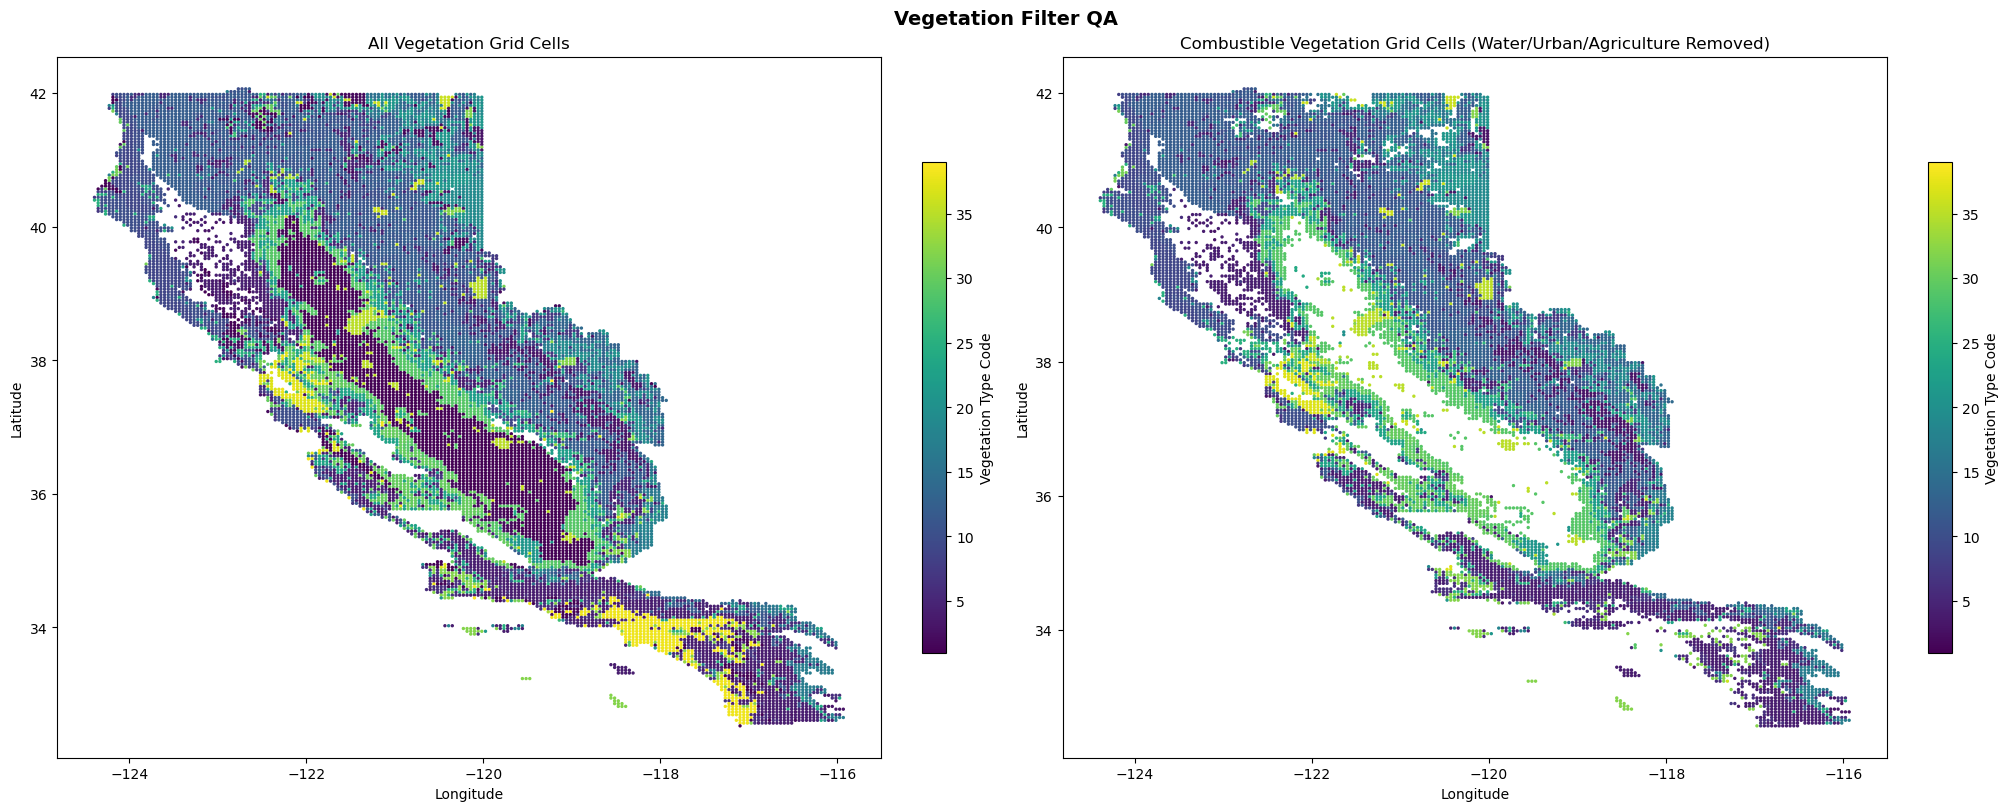

In [14]:
vmin = min(veg_all['type'].min(), veg_filtered['type'].min())
vmax = max(veg_all['type'].max(), veg_filtered['type'].max())

fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

sc1 = axes[0].scatter(
    veg_all['lon'], veg_all['lat'],
    c=veg_all['type'], cmap='viridis', s=2, vmin=vmin, vmax=vmax
)
axes[0].set_title('All Vegetation Grid Cells')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
fig.colorbar(sc1, ax=axes[0], label='Vegetation Type Code', shrink=0.7)

sc2 = axes[1].scatter(
    veg_filtered['lon'], veg_filtered['lat'],
    c=veg_filtered['type'], cmap='viridis', s=2, vmin=vmin, vmax=vmax
)
axes[1].set_title('Combustible Vegetation Grid Cells (Water/Urban/Agriculture Removed)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
fig.colorbar(sc2, ax=axes[1], label='Vegetation Type Code', shrink=0.7)

plt.suptitle('Vegetation Filter QA', fontsize=14, fontweight='bold')
plt.show()

## 9. Apply Vegetation Filter to SWE Data

Load the Phase A Parquet and inner-join with the combustible-vegetation keys.
Print shape before and after to confirm the expected reduction.

In [15]:
filter_keys = veg_filtered[['lon', 'lat']].drop_duplicates()

print(f"Processing started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

swe = pd.read_parquet(phase_a_path)
print(f"Before filter : {swe.shape[0]:,} rows")

swe_filtered = swe.merge(filter_keys, on=['lon', 'lat'], how='inner')
print(f"After filter  : {swe_filtered.shape[0]:,} rows")
print(f"Reduction     : {(1 - swe_filtered.shape[0] / swe.shape[0]) * 100:.1f}%")

del swe
gc.collect()

Processing started: 2026-03-17 13:47:13
Before filter : 605,566,248 rows
After filter  : 141,953,628 rows
Reduction     : 76.6%


15

### Missing Rate After Vegetation Filter

Verify that the vegetation filter does not introduce additional `NaN` values
or distort the per-year pattern observed in Phase A.

In [16]:
missing_filtered = (
    swe_filtered
    .groupby('year')['SWE']
    .apply(lambda x: x.isnull().mean())
    .rename('missing_rate')
    .reset_index()
)
print("Missing rate by year (after vegetation filter):")
print(missing_filtered.to_string(index=False))

Missing rate by year (after vegetation filter):
 year  missing_rate
 1993      0.040364
 1994      0.040364
 1995      0.040364
 1996      0.040364
 1997      0.040364
 1998      0.040364
 1999      0.040364
 2000      0.040364
 2001      0.040364
 2002      0.040364
 2003      0.040364
 2004      0.040364
 2005      0.040364
 2006      0.040364
 2007      0.040364
 2008      0.040364
 2009      0.040364
 2010      0.040364
 2011      0.040364
 2012      0.040364
 2013      0.040364
 2014      0.040364
 2015      0.040364
 2016      0.040364
 2017      0.040364
 2018      0.040364
 2019      0.040364
 2020      0.040364


## 10. Save Final Output

Overwrite the Phase A file with the vegetation-filtered SWE data.
This is the file consumed by the main feature-engineering pipeline.

In [17]:
final_path = os.path.join(SNOW_CLEAN_DIR, 'SWE.parquet')

swe_filtered.to_parquet(final_path, index=False)

print(f"Saved -> {final_path}")
print(f"File size  : {os.path.getsize(final_path) / 1e6:.1f} MB")
print(f"Final shape: {swe_filtered.shape[0]:,} rows × {swe_filtered.shape[1]} cols")
print(f"Columns    : {list(swe_filtered.columns)}")

Saved -> E:\zcao\CA_Wildfire\Clean_Data\Snow_Data\SWE.parquet
File size  : 51.7 MB
Final shape: 141,953,628 rows × 5 cols
Columns    : ['time', 'lat', 'lon', 'SWE', 'year']


## 11. Summary

| Phase | Step | Description | Key Result |
|-------|------|-------------|------------|
| A | Discover | List `.nc` files in `Extended_Data/Snow_Data/` | 1 file |
| A | Inspect | Print dims, time range, coordinates, variables | 1994–2020 daily |
| A | Drop `DEPTH` | Remove unused variable before conversion | Only `SWE` retained |
| A | Convert | Flatten to tidy DataFrame, add `year` column | `(time, lat, lon, SWE, year)` |
| A | Grid QA | Inner-join vs. weather reference grid | All weather cells covered |
| A | Missing Rate | Check `NaN` fraction per year | Expected high in summer |
| A | Save | `SWE.parquet` (unfiltered) | Phase A output |
| B | Load Veg | Read veg-v2, filter Water/Urban/Agriculture | Combustible cells only |
| B | QA Plot | Side-by-side scatter: all vs. filtered grid | Visual confirmation |
| B | Filter | Inner-join SWE × combustible grid | ~10–15% row reduction |
| B | Missing Rate | Re-check `NaN` fraction post-filter | Consistent with Phase A |
| B | Save | Overwrite `SWE.parquet` with filtered data | Final output |